<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Ray_Garza_Random_walk_statistics_and_binomial_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 19: Random Walk Statistics and the Binomial Distribution

## Learning Objectives
By the end of this module you should be able to:
1. Slice a 2D NumPy array to extract particle positions at a specific timestep
2. Plot normalized histograms and interpret them as probability distributions evolving in time
3. Compute ensemble mean and standard deviation using `np.mean` and `np.std` with the correct `axis` argument
4. Explain qualitatively why the spread of random-walk particles grows as $\\sqrt{N}$
5. Simulate the binomial distribution with `rng.binomial` and describe its shape and parameters
6. Convert a binomial sample to a random-walk final-position distribution and verify the $\\sqrt{N}$ spread

---

## Background

In Module 18 we built increasingly efficient code for simulating many 1D random-walk particles simultaneously. The final version, `rw_multi2`, generates a 2D array of shape `(Np, Nstep)` where each row is one particle's full trajectory.

Now we shift attention from *how to simulate* to *what the simulation tells us*. Two key questions:

1. **How does the position distribution of an ensemble of particles change over time?**  
   Particles start clustered at the origin, then spread outward. The distribution at step $n$ is approximately Gaussian with mean $\\mu = 0$ and standard deviation $\\sigma = \\sqrt{n}$.

2. **Why $\\sqrt{n}$?**  
   Each step is an independent $\\pm 1$ coin flip. The final position after $n$ steps is the sum of $n$ independent random variables — the situation described by the **binomial distribution** — and the standard deviation of that sum scales as $\\sqrt{n}$.

Understanding this connection between random walk, the binomial distribution, and ultimately the **Central Limit Theorem** is the goal of this module.

---

## Setup: Rebuild `rw_multi2`

We start from the fully-vectorized multi-particle random-walk function from Module 18. Run the cell below — we will reuse `rmulti` throughout this notebook.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def rw_multi2(Np, N):
    N  = int(N)
    Np = int(Np)
    rng = np.random.default_rng()
    hop    = rng.choice([-1, 1], [Np, N])
    rmulti = np.cumsum(hop, axis=1)
    return rmulti

rmulti = rw_multi2(1e4, 1e3)   # 10 000 particles, 1 000 steps each
print("Shape of rmulti:", rmulti.shape)  # should be (10000, 1000)

Shape of rmulti: (10000, 1000)


---

## Part 1: Position Distributions at Different Timesteps

The 2D array `rmulti` has shape `(Np, Nstep)`. Each **column** contains the positions of all $N_p$ particles at a single timestep. Slicing a column gives a snapshot of the ensemble at that moment — for example, `rmulti[:, -1]` gives positions at the last step, and `rmulti[:, 50]` gives positions at step 50.

> **Q1.1** — Plot three normalized histograms on the same figure: particle positions at step index `50` (early), `500` (middle), and `-1` (final). Use `density=True` and `bins=20`. Add a legend.

> **Q1.2** — Describe how the distribution changes between the three snapshots. What stays the same? What changes?

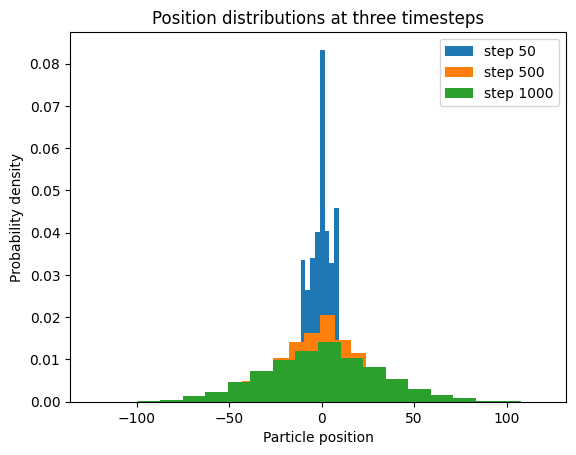

In [17]:
plt.figure()
for step, label in zip([50, 500, -1], ['step 50', 'step 500', 'step 1000']):
    plt.hist(rmulti[:, step], density=True, bins=20, label=label)

plt.xlabel('Particle position')
plt.ylabel('Probability density')
plt.title('Position distributions at three timesteps')
plt.legend()
plt.show()

In [18]:
# The mean (for all three distributions) is centered at the zero origin.
# The step 50 distributions have the highest probability density but the range of particle position is smaller than the rest of the graphs. Step 50 is the inbetween for the distributions in both probability density and particle position. Step 1000 has the smallest range of probability density but the widest range of particle position.

---

## Part 2: Ensemble Mean and Standard Deviation

Instead of snapshots, we can track the **mean** and **standard deviation** of all particle positions *at every step* using `np.mean` and `np.std` with an `axis` argument.

`rmulti` has shape `(Np, Nstep)`. Averaging along `axis=0` collapses the particle dimension and returns one value per step.

> **Q2.1** — Compute `means` and `stds`: arrays of length `Nstep` giving the mean and standard deviation across all particles at each step.

> **Q2.2** — What value do you expect `means` to hover near? Why does the random walk have zero mean regardless of how many steps are taken?

In [19]:
means = np.mean(rmulti, axis=0)
stds  = np.std(rmulti,  axis=0)

print(f"Mean position at final step:    {means[-1]:.3f}")
print(f"Std of positions at final step: {stds[-1]:.2f}")

Mean position at final step:    0.175
Std of positions at final step: 31.68


In [20]:
# I would expect the mean to be somewhere near zero since that is where the graph is centered around. A random walk has a zero mean because each step is a fair coin flip (+1 or -1) with equal probability. These steps are expected to cancel out leading to a mean average of zero.

---

## Part 3: Visualizing the Spread

> **Q3.1** — On a single figure, plot:
> - 20 individual particle trajectories (rows 0–19 of `rmulti`)
> - `means` in black
> - `stds` in blue
>
> Label the axes and add a descriptive title.

> **Q3.2** — Does the standard deviation grow *linearly* (constant speed), *faster*, or *slower* than linear? Make a qualitative judgment from the plot before we verify it analytically.

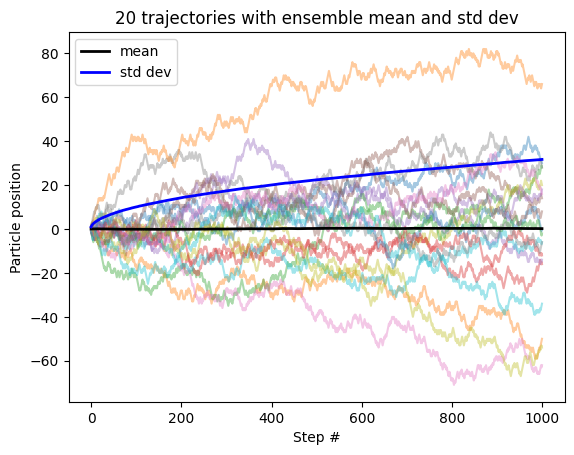

In [21]:
plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.4)
plt.plot(means, 'k-', label='mean',    linewidth=2)
plt.plot(stds,  'b-', label='std dev', linewidth=2)
plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('20 trajectories with ensemble mean and std dev')
plt.legend()
plt.show()

In [22]:
#The std dev grows slower than linearly. The curve starts steep then gradually flattens out.

---

## Part 4: Verifying the $\\sqrt{N}$ Law

The theoretical prediction for the spread of a 1D random walk is

$$\\sigma(n) = \\sqrt{n}$$

where $n$ is the step number.

> **Q4.1** — Create a step array `n = np.arange(1, 1001)` and overlay the curve $\\sqrt{n}$ on the previous figure as a dashed red line. How well does theory match simulation?

> **Q4.2** — What does the $\\sqrt{n}$ growth law imply about how quickly particles spread? To double the spread, how many more steps are needed?

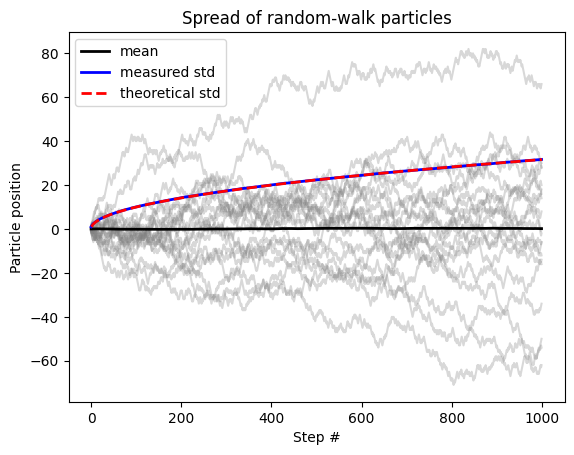

In [23]:
n = np.arange(1, 1001)

plt.figure()
for i in range(20):
    plt.plot(rmulti[i], alpha=0.3, color='gray')
plt.plot(means, 'k-',   label='mean',          linewidth=2)
plt.plot(stds,  'b-',   label='measured std',  linewidth=2)
plt.plot(n, n**0.5, 'r--', label='theoretical std', linewidth=2)

plt.xlabel('Step #')
plt.ylabel('Particle position')
plt.title('Spread of random-walk particles')
plt.legend()
plt.show()

In [24]:
# The theory matches the simulation directly.
# The sqrt(n) growth law implies that the rate of the particle spread decreases as time progresses. To double the spread, quadruple the # of step. If the spread is S after n steps S = sqrt(n), to get a spread of 2S, you would need (2S)^2 = 4S^2 steps. Since S^2 = n, you would need 4n steps.

---

## Part 5: The Binomial Distribution

### Why $\\sqrt{n}$? — A coin-flip model

Every step in a 1D random walk is equivalent to flipping a fair coin: heads $= +1$, tails $= -1$.  
After $n$ flips, the number of heads follows the **binomial distribution**.

NumPy samples from it with:

```python
rng.binomial(n, p, N)
```

- `n` — number of coin flips per experiment  
- `p` — probability of heads  
- `N` — number of independent experiments

> **Q5.1** — Using `n=200, p=0.5`, generate `50` samples and plot a normalized histogram. Where is it centered? Is 50 samples enough to see the shape clearly?

> **Q5.2** — Repeat with `N=100000` samples. What well-known probability distribution does the smooth histogram resemble?

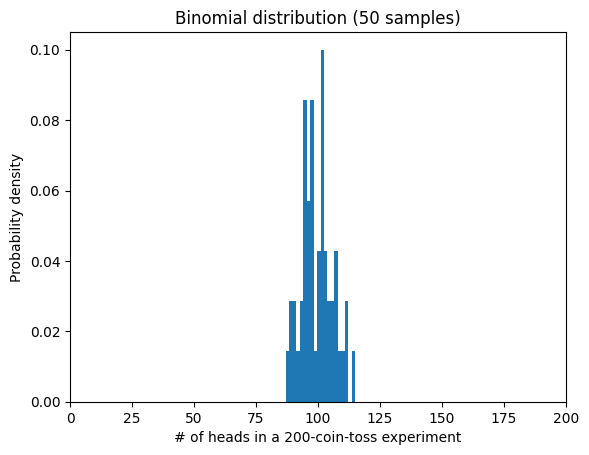

In [25]:
n = 200
p = 0.5

rng = np.random.default_rng()
sample_bino = rng.binomial(n, p, 50)

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (50 samples)')
plt.show()

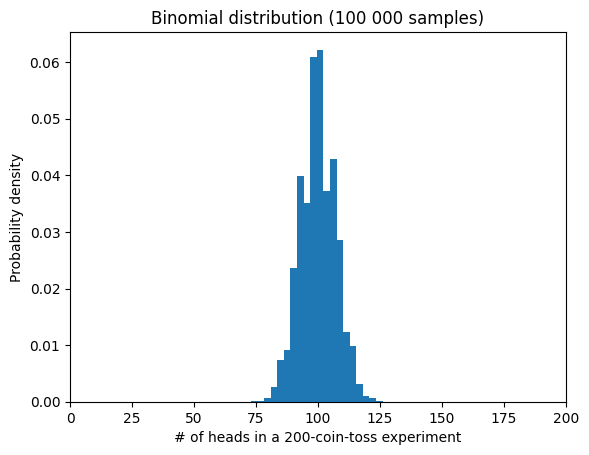

In [26]:
sample_bino = rng.binomial(n, p, 10000)

plt.figure()
plt.hist(sample_bino, density=True, bins=20)
plt.xlim(0, n)
plt.xlabel('# of heads in a 200-coin-toss experiment')
plt.ylabel('Probability density')
plt.title('Binomial distribution (100 000 samples)')
plt.show()

In [27]:
# It is centered at around 100. 50 samples is not enough, the shape is still pretty rough to properly see the distribution.
# When N = 100000, the distribution is centered around 100, and it resembles a Gaussian distribution.

---

## Part 6: Connecting the Binomial Distribution to Random Walk

If a particle flips $n$ coins and gets $k$ heads and $(n-k)$ tails, its final position is

$$x = k \\cdot (+1) + (n - k) \\cdot (-1) = 2k - n.$$

> **Q6.1** — Using `sample_bino` (100 000 samples, `n=200`), compute the random-walk final position `rw` from the formula above. Plot a normalized histogram with `xlim(-n, n)`.

> **Q6.2** — Add two vertical red lines at $x = \\pm\\sqrt{n}$ using `plt.axvline`. Do they align with the spread?

> **Q6.3** — The standard deviation of the binomial is $\\sqrt{n \\cdot p \\cdot (1-p)}$. For $p=0.5$, $n=200$, compute this. After converting to random-walk positions (multiply by 2), what is $\\sigma$? Does it equal $\\sqrt{n}$?

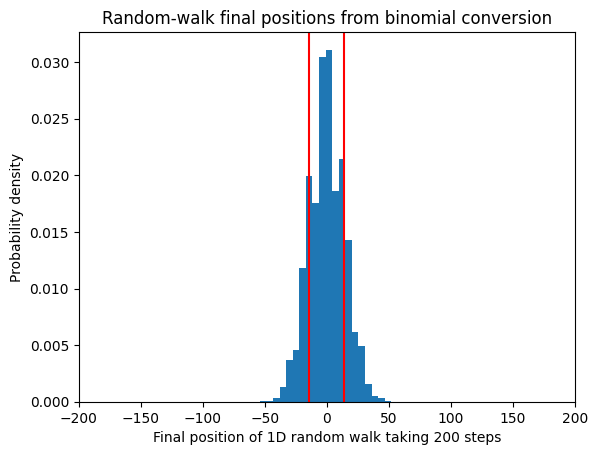

Measured std: 14.19
Expected std (sqrt(n)): 14.14


In [28]:
from matplotlib import color_sequences
# Convert heads to random-walk positions
rw = sample_bino*(+1) + (n-sample_bino)*(-1)

plt.figure()
plt.hist(rw, density=True, bins=20)
plt.xlim(-n, n)
plt.axvline( +np.sqrt(n), color='r')

plt.axvline( -np.sqrt(n), color='r')
plt.xlabel('Final position of 1D random walk taking 200 steps')
plt.ylabel('Probability density')
plt.title('Random-walk final positions from binomial conversion')
plt.show()

print(f"Measured std: {np.std(rw):.2f}")
print(f"Expected std (sqrt(n)): {n**0.5:.2f}")

In [29]:
# Yes, they red lines do align with the distribution.
# The standard deviation 𝜎 has a value of 14.14, while the measured deviation is 14.19, which is close but not exact (due to the flucatuations from only have a finite # of samples).

---

## Summary Questions

> **S1** — We used `axis=0` in `np.mean(rmulti, axis=0)`. Explain in plain language what dimension is being averaged over and what the resulting array represents.

> **S2** — Suppose we had a biased coin with $p=0.7$ (probability of $+1$ step). Would the mean position still be zero after many steps? What would the spread look like?

> **S3** — An ink drop in still water spreads diffusively. If after 1 second the cloud has radius $r$, how large will it be after 4 seconds?

> **S4** — The binomial distribution approaches a Gaussian as $n \\to \\infty$. This is a special case of the **Central Limit Theorem**. State the CLT in your own words and explain why random walk demonstrates it naturally.

In [30]:
# The first dimension is being averaged in axis=0 (all Np particles), the resulting array Nstep represents the position of the particles at a given timestep.
# No, the mean would not be zero. The mean would be some positive value and grow linearly. The spread would grow proportional to sqrt(n) and the distribution would shift to the right.
# The radius would be r * sqrt(4/1)= 2r.
# The Central Limit Theorem means that a distribution sum from a # of independent, random variables will procude a normal distribution. A random walk demonstrates this by making the sum of the independent, random variables (steps) be the final position. As the # of steps increases, the final positions distribution will center at a mean value (usually zero) and the std is proportional to sqrt(n).